In [1]:
import matplotlib.pyplot as plt

from utils.data import DataManager
from utils.tools.config import (
    BENCHMARKS, 
    RISK_ANALYSIS,
    ANALYSIS_START_DATE,
    ANALYSIS_END_DATE
)

from utils.analysis.capm import (
    CAPMAnalyzer,
    PortfolioOptimizationAnalyzer,
    MultiAssetCAPMAnalyzer,
    CAPMReporter,
    PortfolioReporter,
    MultiAssetReporter
)

from utils.visualizations import (
    CAPMVisualizer,
    PortfolioOptimizationVisualizer,
    MultiAssetCAPMVisualizer
)

In [2]:
# 📊 CONFIGURACIÓN DEL ANÁLISIS
# Las fechas vienen de config.py (ANALYSIS_DATES)
# Personaliza aquí solo si necesitas valores diferentes

# Portfolio a analizar
TICKERS = ["META", "AAPL", "GOOGL", "MSFT", "NVDA"]
BENCHMARK_NAME = "SP500"

# (Opcional) Fechas personalizadas - Deja vacío para usar config.py
USE_CUSTOM_DATES = False
START_DATE = ""  # Ej: "2020-01-01"
END_DATE = ""    # Ej: "2024-12-31"

# Constantes desde config
BENCHMARK_TICKER = BENCHMARKS[BENCHMARK_NAME]
RISK_FREE_RATE = RISK_ANALYSIS['risk_free_rate']
ANNUAL_FACTOR = RISK_ANALYSIS['annual_factor']

# Resolver fechas
if USE_CUSTOM_DATES and START_DATE and END_DATE:
    final_start, final_end = START_DATE, END_DATE
    print(f"📅 Usando fechas personalizadas: {final_start} → {final_end}")
else:
    final_start, final_end = ANALYSIS_START_DATE, ANALYSIS_END_DATE
    print(f"📅 Usando fechas de config.py: {final_start} → {final_end}")

print(f"\n📊 Portfolio: {len(TICKERS)} activos")
print(f"📈 Benchmark: {BENCHMARK_NAME} ({BENCHMARK_TICKER})")
print(f"💰 Risk-Free Rate: {RISK_FREE_RATE:.2%}")

📅 Usando fechas de config.py: 2020-01-01 → 2025-12-31

📊 Portfolio: 5 activos
📈 Benchmark: SP500 (^GSPC)
💰 Risk-Free Rate: 4.50%


In [3]:
# 🔧 INICIALIZACIÓN
# Crear DataManager compartido
data_manager = DataManager()

# Inicializar analyzers
capm_analyzer = CAPMAnalyzer(annual_factor=ANNUAL_FACTOR)
portfolio_optimizer = PortfolioOptimizationAnalyzer(annual_factor=ANNUAL_FACTOR)
multi_capm = MultiAssetCAPMAnalyzer(annual_factor=ANNUAL_FACTOR)

# Inicializar reporters
capm_reporter = CAPMReporter(capm_analyzer)
portfolio_reporter = PortfolioReporter(portfolio_optimizer)
multi_asset_reporter = MultiAssetReporter(multi_capm)

# Inicializar visualizers
capm_viz = CAPMVisualizer(capm_analyzer)
portfolio_viz = PortfolioOptimizationVisualizer(portfolio_optimizer)
multi_asset_viz = MultiAssetCAPMVisualizer(multi_capm)

print("✅ Analyzers, reporters y visualizers inicializados")

✅ Analyzers, reporters y visualizers inicializados


In [4]:
# 📥 DESCARGA DE DATOS
print("\n🔄 Descargando datos...")

assets_prices, benchmark_prices = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name=BENCHMARK_NAME,
    start_date=final_start,
    end_date=final_end
)

# Calcular retornos
returns = assets_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

print(f"\n✅ Datos descargados:")
print(f"   Período: {assets_prices.index[0].date()} → {assets_prices.index[-1].date()}")
print(f"   Días: {len(assets_prices)}")
print(f"   Activos: {list(returns.columns)}")


🔄 Descargando datos...
Descargando portafolio completo...
Período: 2020-01-01 → 2025-12-31


[*********************100%***********************]  5 of 5 completed


Período: 2020-01-01 → 2025-12-31


[*********************100%***********************]  1 of 1 completed

Portafolio descargado: 5 activos + benchmark

✅ Datos descargados:
   Período: 2020-01-02 → 2025-12-24
   Días: 1504
   Activos: ['META', 'AAPL', 'GOOGL', 'MSFT', 'NVDA']


In [5]:
# 📈 ANÁLISIS CAPM INDIVIDUAL
# Analiza un activo específico vs el mercado

ASSET_TO_ANALYZE = "META"  # Cambia aquí el ticker

print(f"\n🔍 Analizando {ASSET_TO_ANALYZE} con CAPM...\n")

capm_reporter.generate_report(
    asset_returns=returns[ASSET_TO_ANALYZE].values,
    market_returns=benchmark_returns.values,
    risk_free_rate=RISK_FREE_RATE,
    asset_name=ASSET_TO_ANALYZE
)


🔍 Analizando META con CAPM...

                    ANÁLISIS CAPM: META                     
PARÁMETROS DEL MODELO
  Beta:                       1.325
  Correlación:                0.633
  R²:                         0.400
ALPHA (Jensen)
  Alpha Diario:              0.0436%
  Alpha Anual:                11.62%
SIGNIFICANCIA ESTADÍSTICA
  t-statistic:                0.787
  p-value:                   0.4314
  Significativo (α=0.05):  [NO]
[INFO] Alpha no significativo: el activo se comporta según lo esperado por CAPM


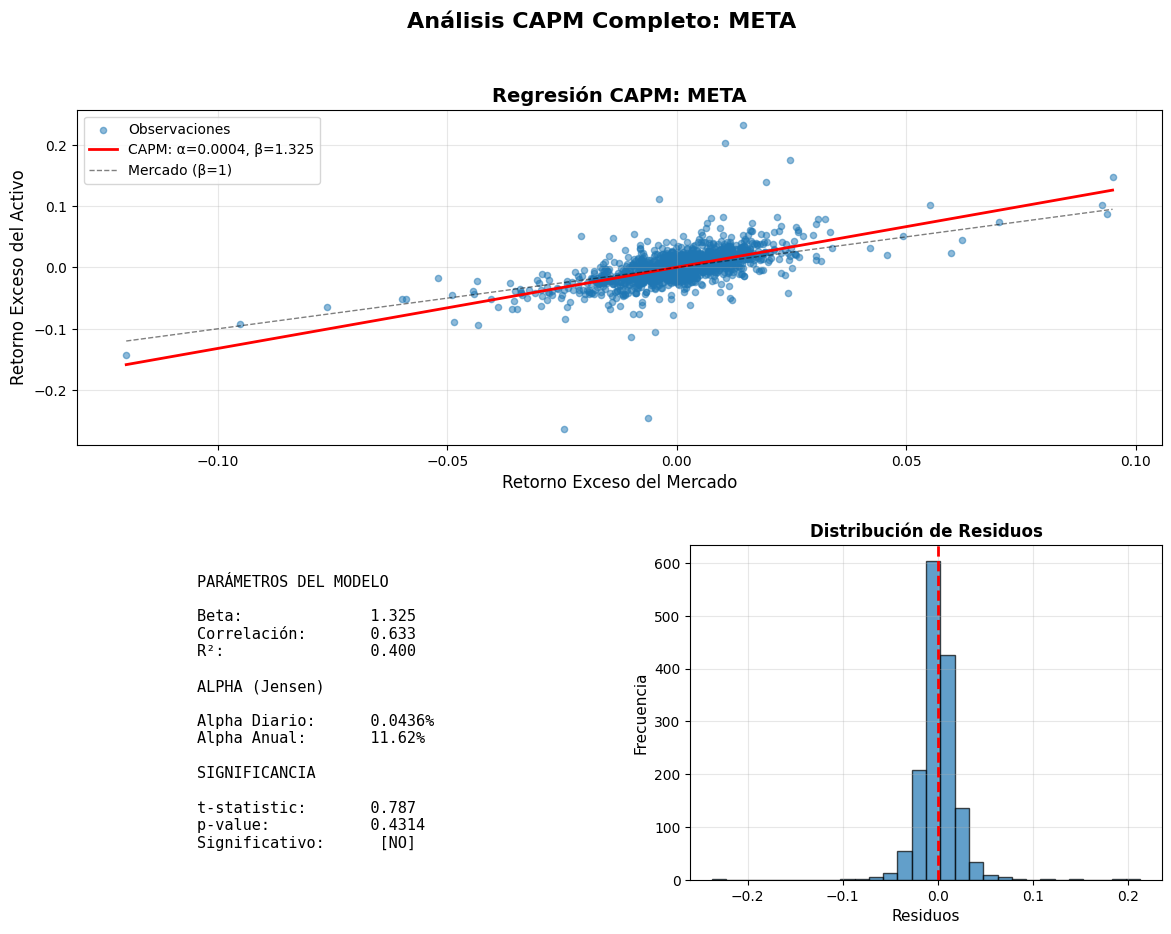

In [6]:
# 📊 VISUALIZACIÓN CAPM INDIVIDUAL
fig1 = capm_viz.plot_capm_analysis(
    asset_returns=returns[ASSET_TO_ANALYZE].values,
    market_returns=benchmark_returns.values,
    risk_free_rate=RISK_FREE_RATE,
    asset_name=ASSET_TO_ANALYZE
)
plt.show()


🔍 Calculando frontera eficiente...



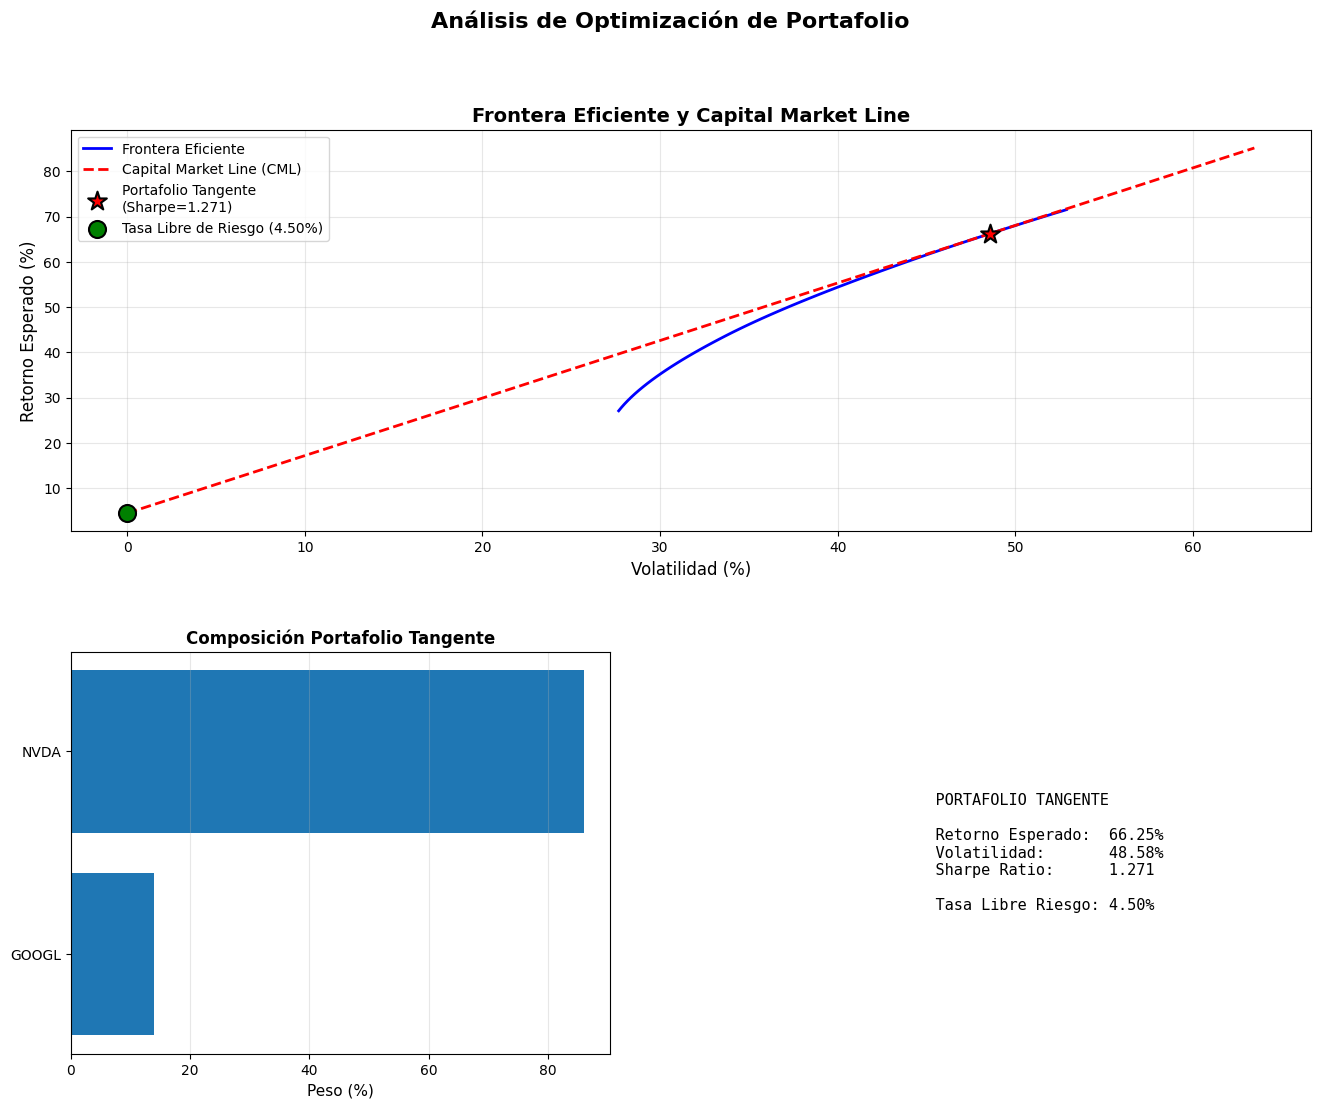

In [7]:
# 🎯 FRONTERA EFICIENTE Y CML
print("\n🔍 Calculando frontera eficiente...\n")

fig2 = portfolio_viz.plot_efficient_frontier_analysis(
    returns=returns,
    risk_free_rate=RISK_FREE_RATE
)
plt.show()

In [8]:
# ⭐ PORTFOLIO TANGENTE (Máximo Sharpe Ratio)
print("\n🔍 Calculando portfolio tangente...\n")

portfolio_reporter.generate_tangent_report(
    returns=returns,
    risk_free_rate=RISK_FREE_RATE
)


🔍 Calculando portfolio tangente...

            PORTAFOLIO TANGENTE (Máximo Sharpe)             
CARACTERÍSTICAS
  Retorno Esperado:           66.25%
  Volatilidad:                48.58%
  Sharpe Ratio:               1.271
COMPOSICIÓN DEL PORTAFOLIO
  NVDA         86.06%
  GOOGL        13.94%


In [9]:
# 📊 ANÁLISIS CAPM MULTI-ACTIVO (Resumen)
print("\n🔍 Analizando todos los activos con CAPM...\n")

multi_asset_reporter.generate_summary_report(
    returns=returns,
    market_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)


🔍 Analizando todos los activos con CAPM...

                           ANÁLISIS CAPM MULTI-ACTIVO                           
Activos analizados: 5
ESTADÍSTICAS GENERALES
  Beta promedio:              1.313
  Alpha promedio (anual):     21.93%
  R² promedio:                0.537

[OK] Alphas significativos: 1 / 5
TOP 5 PERFORMERS (Alpha más alto)
  [OK] NVDA       Alpha:   63.12%  Beta:  1.784
       GOOGL      Alpha:   15.93%  Beta:  1.126
       META       Alpha:   11.62%  Beta:  1.325
       AAPL       Alpha:   11.13%  Beta:  1.190
       MSFT       Alpha:    7.83%  Beta:  1.139
BOTTOM 5 PERFORMERS (Alpha más bajo)
       MSFT       Alpha:    7.83%  Beta:  1.139
       AAPL       Alpha:   11.13%  Beta:  1.190
       META       Alpha:   11.62%  Beta:  1.325
       GOOGL      Alpha:   15.93%  Beta:  1.126
  [OK] NVDA       Alpha:   63.12%  Beta:  1.784
Nota: [OK] indica alpha estadísticamente significativo (p < 0.05)


In [10]:
# 📋 TABLA DE RESULTADOS CAPM
capm_results = multi_capm.analyze_multiple(
    returns=returns,
    market_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)

print("\n📊 Resultados detallados de CAPM:\n")
display(capm_results)


📊 Resultados detallados de CAPM:



,alpha_daily,alpha_annual,beta,correlation,r_squared,t_statistic,p_value,is_significant
asset,,,,,,,,
NVDA,0.001944,0.631212,1.784482,0.702103,0.492949,3.122045,0.001830,True
GOOGL,0.000587,0.159284,1.125975,0.725552,0.526426,1.730982,0.083661,False
META,0.000436,0.116156,1.324794,0.632625,0.400215,0.786960,0.431429,False
AAPL,0.000419,0.111286,1.190236,0.782939,0.612993,1.292935,0.196233,False
MSFT,0.000299,0.078330,1.139262,0.806814,0.650949,1.147424,0.251389,False


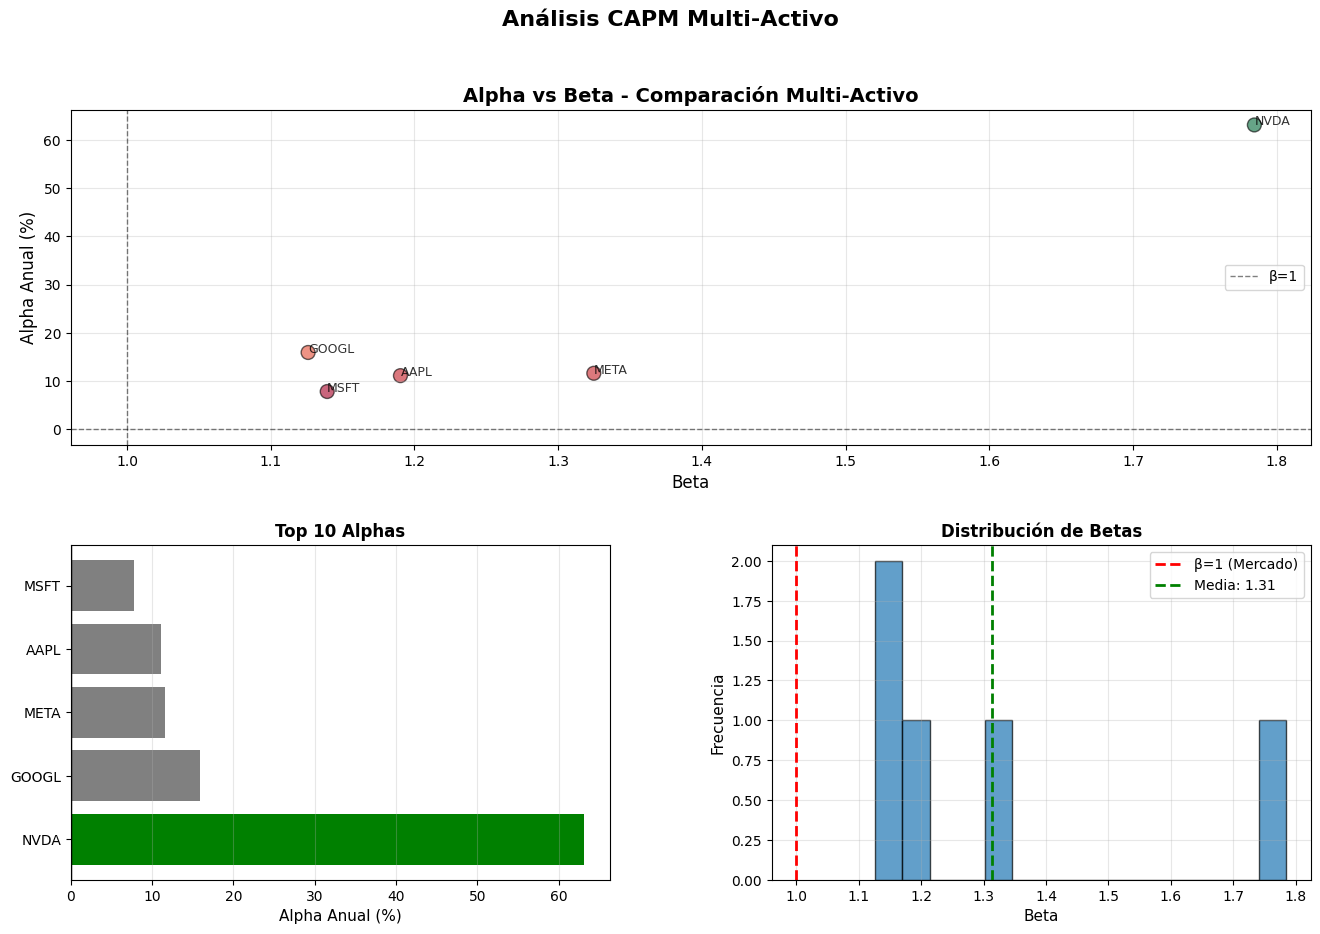

In [11]:
# 📊 VISUALIZACIÓN MULTI-ACTIVO
fig3 = multi_asset_viz.plot_multi_asset_analysis(
    returns=returns,
    market_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)
plt.show()

In [14]:
# 🔬 ANÁLISIS CAPM INDIVIDUAL
print("🔬 Análisis CAPM por activo:\n")
print(f"{'Ticker':<8} {'Alpha':<10} {'Beta':<8} {'R²':<8} {'Sig':<5}")
print("-" * 50)

for ticker in TICKERS:
    capm_result = capm_analyzer.analyze(
        asset_returns=returns[ticker].values,
        market_returns=benchmark_returns.values,
        risk_free_rate=RISK_FREE_RATE
    )
    
    is_sig = "✓" if capm_result['is_significant'] else "✗"
    
    print(f"{ticker:<8} {capm_result['alpha_annual']:>8.2%}  "
          f"{capm_result['beta']:>6.3f}  "
          f"{capm_result['r_squared']:>6.3f}  {is_sig:<5}")

🔬 Análisis CAPM por activo:

Ticker   Alpha      Beta     R²       Sig  
--------------------------------------------------
META       11.62%   1.325   0.400  ✗    
AAPL       11.13%   1.190   0.613  ✗    
GOOGL      15.93%   1.126   0.526  ✗    
MSFT        7.83%   1.139   0.651  ✗    
NVDA       63.12%   1.784   0.493  ✓    
